In [1]:
import torch 
import torch.nn as nn
import torchvision

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter

from pathlib import Path

import matplotlib.pyplot as plt

from torchinfo import summary

from modules import engine, utils

c:\Python Latop\razerblade-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
IMG_SIZE = 224

manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
data_path = Path("data")
train_path = data_path / "train"
test_path = data_path / "test"

train_data = datasets.ImageFolder(train_path, transform=manual_transforms)
test_data = datasets.ImageFolder(test_path, transform=manual_transforms)
train_dataloader = DataLoader(train_data, batch_size=16)
test_dataloader = DataLoader(test_data, batch_size=16)



(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

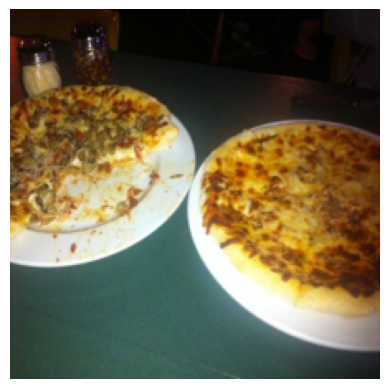

In [4]:
images, labels = next(iter(train_dataloader))
image = images[0]
plt.imshow(image.permute(1,2,0))
plt.axis("off")

In [5]:
IMAGE_SIZE = 224
PATCH_SIZE = 16
NUM_PATCHES = IMAGE_SIZE**2 // PATCH_SIZE**2

In [6]:
image.dtype

torch.float32

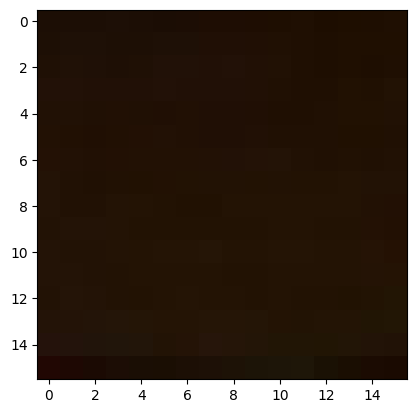

In [7]:
plt.imshow(image.permute(1,2,0)[:PATCH_SIZE,:PATCH_SIZE,:])

In [8]:
def plot_patched_images(image, patch_size):
    image_permuted = image.permute(1,2,0)
    height = image_permuted.shape[0]
    width = image_permuted.shape[1]
    rows = height // patch_size
    cols = width // patch_size
    patches = rows * cols


    fig, axes = plt.subplots(rows, cols, figsize=(rows, cols))
    for i in range(rows):
        for j in range(cols):
            axes[i,j].imshow(image_permuted[i*patch_size:(i+1)*patch_size,j*patch_size:(j+1)*patch_size,:])
            axes[i,j].set_xticks([])
            axes[i,j].set_yticks([])
            if j == 0:
                axes[i,j].set_ylabel(i+1, rotation=0, labelpad=10)
            if i == rows-1:
                axes[i,j].set_xlabel(j+1)
        
    

        



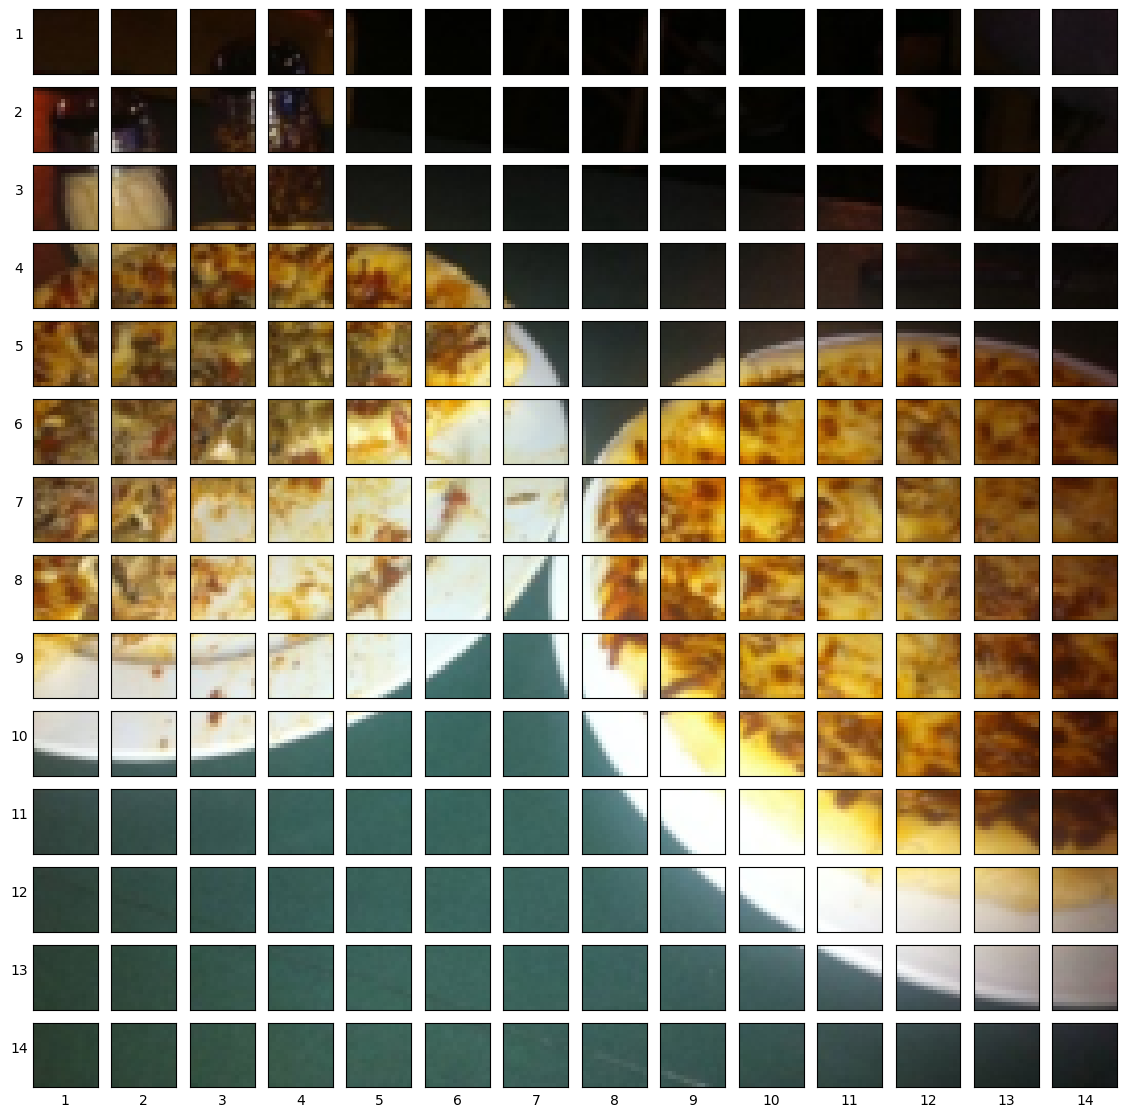

In [9]:
plot_patched_images(image, 16)

In [10]:
conv2d = nn.Conv2d(in_channels= 3,
                   out_channels=768,
                   kernel_size=16,
                   stride=16,
                   padding=0)

In [11]:
image_passed = conv2d(image.unsqueeze(dim=0))
image_passed.flatten(start_dim=2, end_dim=3).permute(0,2,1).shape

torch.Size([1, 196, 768])

In [12]:
class patch_emmbedding(nn.Module):

    def __init__(self,
                 in_channels:int=3,
                 patch_size:int=16,
                 embedding_dim:int=768):
        super().__init__()
        self.patch_size = patch_size
        self.encode = nn.Conv2d(in_channels= in_channels,
                   out_channels=embedding_dim,
                   kernel_size= patch_size,
                   stride=patch_size,
                   padding=0)
        
        self.flatten = nn.Flatten(start_dim = 2, end_dim = 3)


    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0
        x = self.encode(x)
        x = self.flatten(x)
        return x.permute(0,2,1)

In [13]:
patched = patch_emmbedding()
image_passed = patched(image.unsqueeze(dim=0))
image_passed.shape

torch.Size([1, 196, 768])

In [14]:
summary(patch_emmbedding(),
        input_size=(1, 3, 224, 224), # try swapping this for "random_input_image_error"
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
patch_emmbedding (patch_emmbedding)      [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (encode)                        [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

In [15]:
batch_size = image_passed.shape[0]
embedding_dimension = image_passed.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), requires_grad=True)

In [16]:
patch_embedded_image_with_class_embedding = torch.cat((class_token, image_passed),
                                                      dim=1)

In [17]:
patch_embedded_image_with_class_embedding.shape

torch.Size([1, 197, 768])

Query (Q) — "What am I looking for?" — the current token asking a question
Key (K) — "What do I have to offer?" — every token advertising its content
Value (V) — "Here's my actual content" — what gets retrieved if the key matches

In [18]:
class MultiheadSelfAttentionBlock(nn.Module):
    def __init__(self,
                 embedding_dimension:int = 768,
                 num_heads:int = 12,
                 attn_dropout:float = 0):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape = embedding_dimension)

        self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dimension,
                                                    num_heads=num_heads,
                                                    dropout=attn_dropout,
                                                    batch_first=True)
        
    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, attn_weights = self.multihead_attn(query=x,
                                    key=x,
                                    value=x,
                                    need_weights=False)
        return attn_output 
        


In [19]:
class MultiheadPerceptronBlock(nn.Module):
    def __init__(self,
                 embedding_dimension:int = 768,
                 mlp_size:int = 3072,
                 dropout:float = 0.1):
        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dimension)

        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dimension,out_features=mlp_size),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, out_features= embedding_dimension),
            nn.GELU(),
            nn.Dropout(p=dropout)
        )
    
    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        return x 

In [20]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self,
                 embedding_dimension:int = 768,
                 num_heads:int = 12,
                 mlp_size:int = 3072,
                 mlp_dropout:float = 0.1,
                 attn_dropout:float = 0):
        super().__init__()

        self.msa = MultiheadSelfAttentionBlock(embedding_dimension=embedding_dimension,
                                            num_heads=num_heads,
                                            attn_dropout=attn_dropout)
        
        self.mlp = MultiheadPerceptronBlock(embedding_dimension=embedding_dimension,
                                            mlp_size=mlp_size,
                                            dropout=mlp_dropout)
        
    def forward(self, x):
        x = self.msa(x) + x
        x = self.mlp(x) + x
        return x

In [21]:
class ViT(nn.Module):
    def __init__(self,
                 img_size:int = 224,
                 in_channels:int=3,
                 patch_size:int=16,
                 num_transformer_layers:int=12,
                 embedding_dimension:int = 768,
                 msa_numheads:int = 12,
                 mlp_size:int = 3072,
                 mlp_dropout:float = 0,
                 attn_dropout:float = .1,
                 embedding_dropout:int = 0,
                 num_classes:int = 3):
        super().__init__()

        assert img_size % patch_size == 0
        self.num_patches = img_size**2 // patch_size **2

        self.patch_embedding = patch_emmbedding(in_channels=in_channels,
                                               patch_size=patch_size,
                                               embedding_dim= embedding_dimension)

        self.class_embedding = nn.Parameter(torch.randn(1, 1, embedding_dimension))

        
        self.position_embedding = nn.Parameter(torch.rand(1, self.num_patches + 1, embedding_dimension),
                                              requires_grad=True)
        
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(embedding_dimension=embedding_dimension,
                                                    mlp_dropout=mlp_dropout,
                                                    num_heads=msa_numheads,
                                                    mlp_size=mlp_size,
                                                    attn_dropout=attn_dropout) for _ in range(num_transformer_layers)])
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dimension),
            nn.Linear(in_features=embedding_dimension,
                      out_features=num_classes)
        )

    def forward(self, x):
        batch_size = x.shape[0]
        x = self.patch_embedding(x)
        class_token = self.class_embedding.expand(batch_size, -1, -1)
        x = torch.cat((class_token, x), dim=1)
        x = self.position_embedding + x
        x = self.embedding_dropout(x)
        x = self.transformer_encoder(x)
        x = self.classifier(x[:,0])
        return x


        



In [22]:
Vit_model = ViT()

In [23]:
test = Vit_model(torch.rand((3, 3, 224, 224)))

In [44]:
optimizer = torch.optim.Adam(params=Vit_model.parameters(),
                             lr=3e-3,
                             betas=(0.9, 0.999),
                             weight_decay=0.3)

# Setup the loss function for multi-class classification
loss_fn = torch.nn.CrossEntropyLoss()

# Set the seeds

torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train the model and save the training results to a dictionary
results = engine.train(model=Vit_model.to(device),
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=1,
                       device=device)

Training: 100%|██████████| 15/15 [00:05<00:00,  2.75it/s]


epoch 1 / 1
Train loss: 0.9659511099259058
Train acc: 0.5708333333333333


Testing: 100%|██████████| 5/5 [00:00<00:00,  6.00it/s]


Test loss: 1.3992478877305985
Test acc: 0.45
Saving model to: models\05_going_modular_script_mode.pth


100%|██████████| 1/1 [00:06<00:00,  6.83s/it]


In [46]:
test = Vit_model(torch.rand((5, 3, 224, 224)).to(device))

In [48]:
torch.softmax(test, dim=1)

tensor([[0.0818, 0.1650, 0.7532],
        [0.0819, 0.1653, 0.7528],
        [0.0818, 0.1649, 0.7533],
        [0.0819, 0.1652, 0.7530],
        [0.0819, 0.1652, 0.7529]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

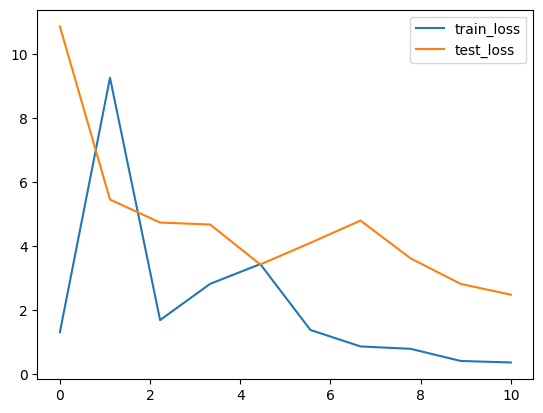

In [ ]:
import numpy as np
plt.plot(np.linspace(0, 10, 10), results["train_loss"], label = "train_loss")
plt.plot(np.linspace(0, 10, 10), results["test_loss"], label = "test_loss")
plt.legend()

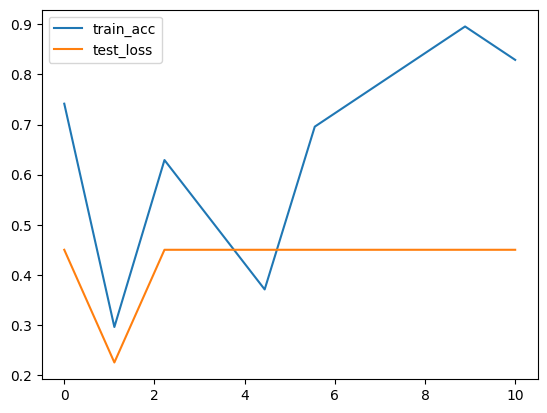

In [ ]:
plt.plot(np.linspace(0, 10, 10), results["train_acc"], label = "train_acc")
plt.plot(np.linspace(0, 10, 10), results["test_acc"], label = "test_loss")
plt.legend()

In [ ]:
len(results["train_loss"])

10